In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [2]:
df = pd.read_csv("../../course_assignments/homework9/solar_system.csv")
df

,Attribute,Mercury,Venus,Earth,Moon,Mars,Jupiter,Saturn,Uranus,Neptune,Pluto
0,Mass (10^24kg),0.330,4.87,5.97,0.073,0.642,1898,568,86.8,102,0.0130
1,Diameter (km),4879,12104,12756,3475,6792,142984,120536,51118,49528,2376
2,Density (kg/m^3),5429,5243,5514,3340,3934,1326,687,1270,1638,1850
3,Gravity (m/s^2),3.7,8.9,9.8,1.6,3.7,23.1,9.0,8.7,11.0,0.7
4,Escape Velocity (km/s),4.3,10.4,11.2,2.4,5.0,59.5,35.5,21.3,23.5,1.3
5,Rotation Period (hours),1407.6,-5832.5,23.9,655.7,24.6,9.9,10.7,-17.2,16.1,-153.3
6,Length of Day (hours),4222.6,2802.0,24.0,708.7,24.7,9.9,10.7,17.2,16.1,153.3
7,Distance from Sun (10^6 km),57.9,108.2,149.6,0.384,228.0,778.5,1432.0,2867.0,4515.0,5906.4
8,Perihelion (10^6 km),46.0,107.5,147.1,0.363,206.7,740.6,1357.6,2732.7,4471.1,4436.8
9,Aphelion (10^6 km),69.8,108.9,152.1,0.406,249.3,816.4,1506.5,3001.4,4558.9,7375.9


In [3]:
df.shape
# The shape of the dataset is 20 x 11
# This means there are 20 rows and 11 columns

(20, 11)

In [4]:
df.head()

,Attribute,Mercury,Venus,Earth,Moon,Mars,Jupiter,Saturn,Uranus,Neptune,Pluto
0,Mass (10^24kg),0.330,4.87,5.97,0.073,0.642,1898,568,86.8,102,0.0130
1,Diameter (km),4879,12104,12756,3475,6792,142984,120536,51118,49528,2376
2,Density (kg/m^3),5429,5243,5514,3340,3934,1326,687,1270,1638,1850
3,Gravity (m/s^2),3.7,8.9,9.8,1.6,3.7,23.1,9.0,8.7,11.0,0.7
4,Escape Velocity (km/s),4.3,10.4,11.2,2.4,5.0,59.5,35.5,21.3,23.5,1.3


In [5]:
df.tail()

,Attribute,Mercury,Venus,Earth,Moon,Mars,Jupiter,Saturn,Uranus,Neptune,Pluto
15,Mean Temperature (C),167,464,15,-20,-65,-110,-140,-195,-200,-225
16,Surface Pressure (bars),0,92,1,0,0.01,Unknown,Unknown,Unknown,Unknown,0.00001
17,Number of Moons,0,0,1,0,2,95,274,28,16,5
18,Ring System?,No,No,No,No,No,Yes,Yes,Yes,Yes,No
19,Global Magnetic Field?,Yes,No,Yes,No,No,Yes,Yes,Yes,Yes,Unknown


In [6]:
for name in df.columns:
    print(name)
# Below are the column names

Attribute
Mercury
Venus
Earth
Moon
Mars
Jupiter
Saturn
Uranus
Neptune
Pluto


In [7]:
for name in df["Attribute"]:
    print(name)
# Below are the row names

Mass (10^24kg)
Diameter (km)
Density (kg/m^3)
Gravity (m/s^2)
Escape Velocity (km/s)
Rotation Period (hours)
Length of Day (hours)
Distance from Sun (10^6 km)
Perihelion (10^6 km)
Aphelion (10^6 km)
Orbital Period (days)
Orbital Velocity (km/s)
Orbital Inclination (deg)
Orbital Eccentricity
Obliquity to Orbit (deg)
Mean Temperature (C)
Surface Pressure (bars)
Number of Moons
Ring System?
Global Magnetic Field?


In [8]:
orbital_period = df.iloc[10, 1:].astype(float)
perihelion = df.iloc[8, 1:].astype(float)
aphelion = df.iloc[9, 1:].astype(float)

In [9]:
# The Semi major axis (of a planetary body's orbit) is the distance measuring the
# widest part of the orbit.
# The perihelion is the position in this orbit where the planetary body is 
# closest to the sun.
# The position of the planetary body in its orbit where it is furthest from the
# sun is called the aphelion.

In [10]:
semi_major_axis = (perihelion + aphelion) / 2
semi_major_axis
new_row = pd.Series(["Semi-major Axis (10^6 km)", *semi_major_axis.values], index=df.columns)
df = pd.concat([df, new_row.to_frame().T], ignore_index=True)
df
# There are now 22 rows, but still 11 columns

,Attribute,Mercury,Venus,Earth,Moon,Mars,Jupiter,Saturn,Uranus,Neptune,Pluto
0,Mass (10^24kg),0.330,4.87,5.97,0.073,0.642,1898,568,86.8,102,0.0130
1,Diameter (km),4879,12104,12756,3475,6792,142984,120536,51118,49528,2376
2,Density (kg/m^3),5429,5243,5514,3340,3934,1326,687,1270,1638,1850
3,Gravity (m/s^2),3.7,8.9,9.8,1.6,3.7,23.1,9.0,8.7,11.0,0.7
4,Escape Velocity (km/s),4.3,10.4,11.2,2.4,5.0,59.5,35.5,21.3,23.5,1.3
5,Rotation Period (hours),1407.6,-5832.5,23.9,655.7,24.6,9.9,10.7,-17.2,16.1,-153.3
6,Length of Day (hours),4222.6,2802.0,24.0,708.7,24.7,9.9,10.7,17.2,16.1,153.3
7,Distance from Sun (10^6 km),57.9,108.2,149.6,0.384,228.0,778.5,1432.0,2867.0,4515.0,5906.4
8,Perihelion (10^6 km),46.0,107.5,147.1,0.363,206.7,740.6,1357.6,2732.7,4471.1,4436.8
9,Aphelion (10^6 km),69.8,108.9,152.1,0.406,249.3,816.4,1506.5,3001.4,4558.9,7375.9


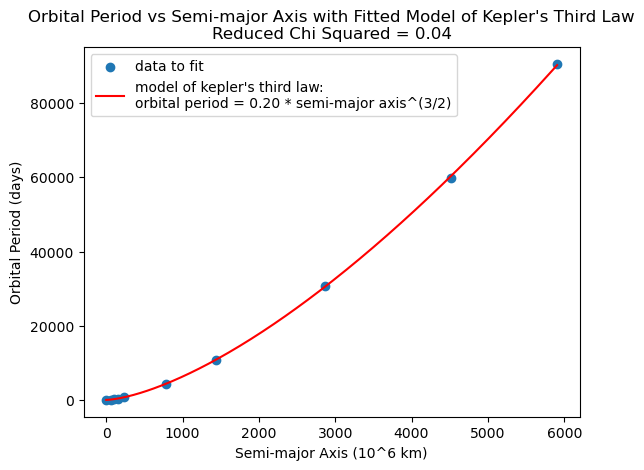

In [19]:
plt.figure
plt.scatter(semi_major_axis, orbital_period, label = "data to fit")
plt.xlabel("Semi-major Axis (10^6 km)")
plt.ylabel("Orbital Period (days)")

def keplers_third_law(a,m):
    return m * a ** 1.5

popt, pcov = curve_fit(keplers_third_law, semi_major_axis, orbital_period)
m_fit = popt[0]
x = np.linspace(min(semi_major_axis), max(semi_major_axis), 200)
plt.plot(x, keplers_third_law(x, m_fit), color = "red", label = f"model of kepler's third law:\norbital period = {m_fit:.2f} * semi-major axis^(3/2)")

residuals = orbital_period - keplers_third_law(semi_major_axis, m_fit)
chi2 = np.sum(residuals**2)
dof = len(semi_major_axis) - len(popt)
chi2_reduced = chi2 / dof
chi2_reduced_fix_scale = chi2_reduced / (10 ** 6)

plt.title(f"Orbital Period vs Semi-major Axis with Fitted Model of Kepler's Third Law\nReduced Chi Squared = {chi2_reduced_fix_scale:.2f}")
plt.legend()
plt.show()


# print(f"Fit: y = {A_fit:.2f} * e^(-{k_fit:.2f} * x)")
# residuals = y - model(x, A_fit, k_fit)
# chi2 = np.sum(residuals**2)
# dof = len(x) - len(popt)
# chi2_reduced = chi2 / dof
# print(f"Reduced chi2_reduced: {chi2_reduced:.2f}")

In [20]:
df.to_csv("kepler", index=False)